In [1]:
import matplotlib.pyplot as plt
import numpy as np
import PIL
import tensorflow as tf
import pandas as pd
import time

from tensorflow import keras
from tensorflow.keras import layers
from tensorflow.keras.models import Sequential

2025-08-29 05:37:50.584582: E external/local_xla/xla/stream_executor/cuda/cuda_fft.cc:477] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
E0000 00:00:1756445870.859668      36 cuda_dnn.cc:8310] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
E0000 00:00:1756445870.938337      36 cuda_blas.cc:1418] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered


# Import Data

In [2]:
batch_size = 32
img_height = 32 
img_width = 32

In [3]:
train_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/devanagari-character-dataset-large/dhcd/train",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

Found 78200 files belonging to 46 classes.


2025-08-29 05:38:39.621387: E external/local_xla/xla/stream_executor/cuda/cuda_driver.cc:152] failed call to cuInit: INTERNAL: CUDA error: Failed call to cuInit: UNKNOWN ERROR (303)


In [4]:
val_ds = tf.keras.utils.image_dataset_from_directory(
    "/kaggle/input/devanagari-character-dataset-large/dhcd/test",
    seed=123,
    image_size=(img_height, img_width),
    batch_size=batch_size,
    color_mode='grayscale'
)

Found 13800 files belonging to 46 classes.


In [5]:
class_names = train_ds.class_names
print(class_names)

['0', '1', '10', '11', '12', '13', '14', '15', '16', '17', '18', '19', '2', '20', '21', '22', '23', '24', '25', '26', '27', '28', '29', '3', '30', '31', '32', '33', '34', '35', '36', '37', '38', '39', '4', '40', '41', '42', '43', '44', '45', '5', '6', '7', '8', '9']


In [6]:
labels_csv = pd.read_csv("/kaggle/input/devanagari-character-dataset-large/labels.csv")
labels_csv.head()

,Class,Label,Devanagari label,Phonetic,Type
0,0,0,०,Śūn'ya,DIGIT
1,1,1,१,ēka,DIGIT
2,2,2,२,du'ī,DIGIT
3,3,3,३,tīna,DIGIT
4,4,4,४,cāra,DIGIT


In [7]:
labels_csv.loc[30, 'Devanagari label']

'प'

ष
थ
९
घ
ब
८
ल
८
म


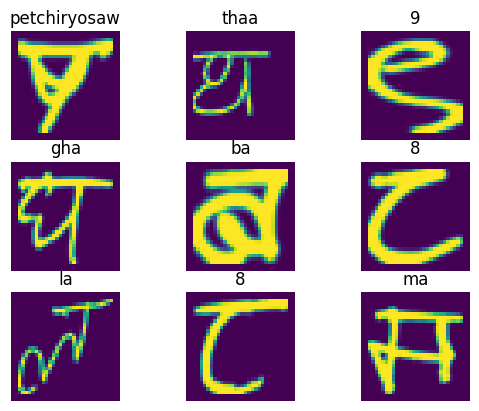

In [8]:
import matplotlib.pyplot as plt

# plt.figure(figsize=(10, 10))
for images, labels in train_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    plt.imshow(images[i].numpy().astype("uint8"))
#     print(images[i].numpy().astype("uint8").shape)
#     print(labels[i])    #folder ko index print garxa
#     plt.title(class_names[labels[i]]) #folder ko naam print garxa
    class_name = int(class_names[labels[i]])
    print(labels_csv.loc[class_name, 'Devanagari label'])
    plt.title(labels_csv.loc[class_name, 'Label'])
    plt.axis("off")

In [9]:
AUTOTUNE = tf.data.AUTOTUNE

train_ds = train_ds.cache().shuffle(1000).prefetch(buffer_size=AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)

In [32]:
from tensorflow.keras.callbacks import EarlyStopping

early_stop = EarlyStopping(
    monitor='val_loss', 
    patience=5,        # stop if no improvement for 5 epochs
    restore_best_weights=True
)


# Creating model

In [73]:
num_classes = len(class_names)

model = Sequential([
    layers.Input(shape=(32,32,1)),
    layers.Rescaling(1./255),
    layers.Flatten(),
    layers.Dense(100,activation="relu"),
    layers.Dropout(0.1),
    layers.Dense(num_classes, activation="softmax")
])


In [74]:
model.summary()


Model: "sequential_10"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling_8 (Rescaling)         │ (None, 32, 32, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_9 (Flatten)             │ (None, 1024)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_18 (Dense)                │ (None, 100)            │       102,500 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_7 (Dropout)             │ (None, 100)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_19 (Dense)                │ (None, 46)             │         4,646 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 107,146 (418.54 KB)

 Trainable params: 107,146 (418.54 KB)

 Non-trainable params: 0 (0.00 B)

# Compiling Model


In [75]:
model.compile(optimizer="adam",
              loss="sparse_categorical_crossentropy",
              metrics=["accuracy"])

# Training Model

In [76]:
epochs=40
time1 = time.time()

history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs,
  callbacks=[early_stop]
)
time2 = time.time()

print("Train time = ", (time2-time1)/60, "min")

Epoch 1/40
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 12s 4ms/step - accuracy: 0.5424 - loss: 1.7538 - val_accuracy: 0.7991 - val_loss: 0.7174
Epoch 2/40
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7898 - loss: 0.7486 - val_accuracy: 0.8508 - val_loss: 0.5319
Epoch 3/40
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8307 - loss: 0.5813 - val_accuracy: 0.8729 - val_loss: 0.4579
Epoch 4/40
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8524 - loss: 0.5058 - val_accuracy: 0.8833 - val_loss: 0.4113
Epoch 5/40
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8641 - loss: 0.4601 - val_accuracy: 0.8886 - val_loss: 0.3919
Epoch 6/40
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 11s 4ms/step - accuracy: 0.8764 - loss: 0.4141 - val_accuracy: 0.8917 - val_loss: 0.3775
Epoch 7/40
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8840 - loss: 0.3872 - val_accuracy: 0.8981 - val_loss: 0.3617
Epoch 8/40
2444/2444 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.8871 - loss: 0

# Visualize training results


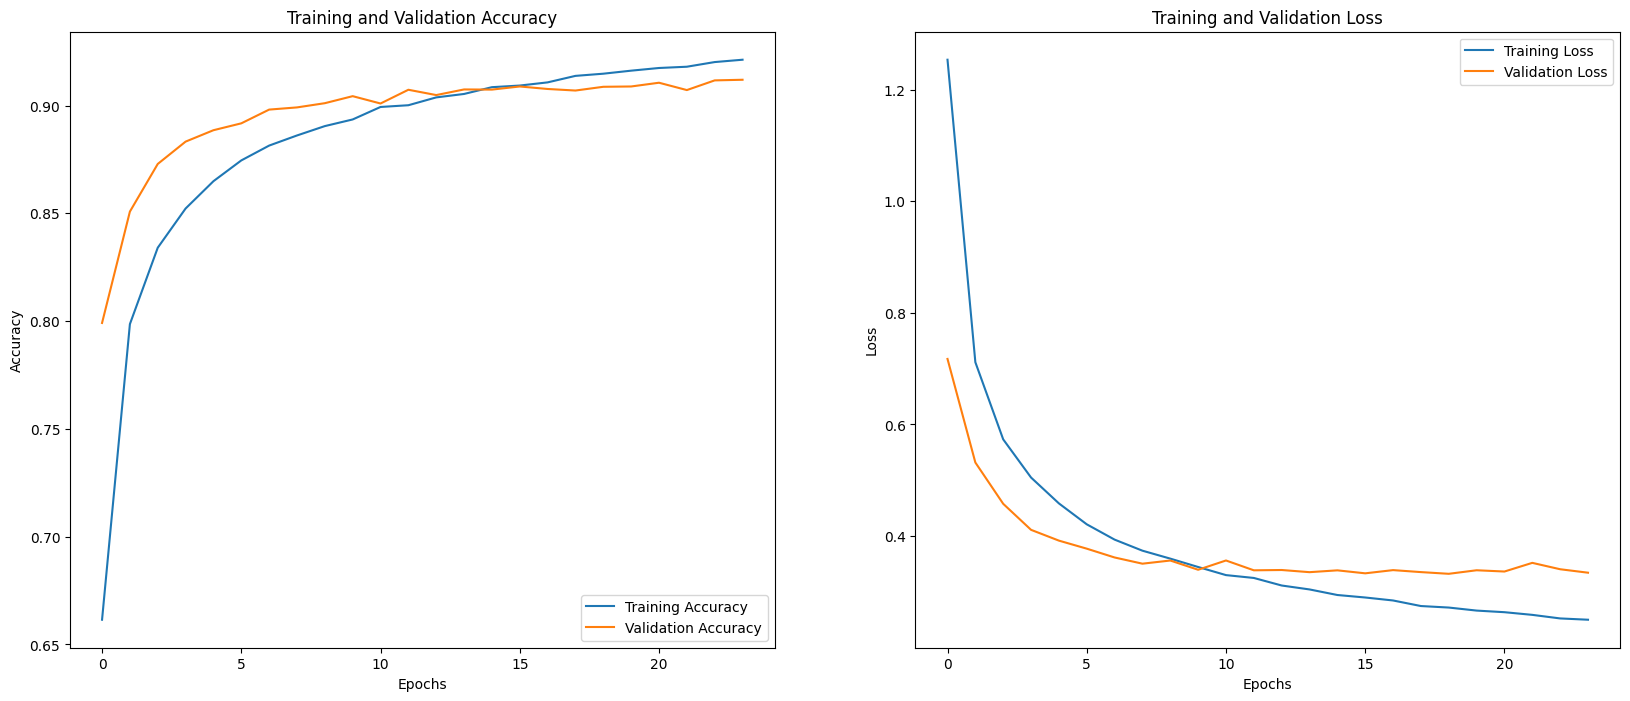

In [77]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

# Dynamically set epochs range according to training
epochs_range = range(len(acc))

plt.figure(figsize=(20, 8))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epochs')
plt.ylabel('Accuracy')

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')

plt.show()


# Saving Model

In [78]:
model.save('my_model.keras')

In [79]:
new_model1 = tf.keras.models.load_model('my_model.keras')

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 87ms/step
Actual- ९   Prediction- ९
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 46ms/step
Actual- भ   Prediction- भ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Actual- ढ   Prediction- द
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 43ms/step
Actual- ठ   Prediction- ज
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 45ms/step
Actual- १   Prediction- १
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Actual- ध   Prediction- ध
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 44ms/step
Actual- फ   Prediction- छ
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 40ms/step
Actual- ७   Prediction- ७
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 41ms/step
Actual- ण   Prediction- ण


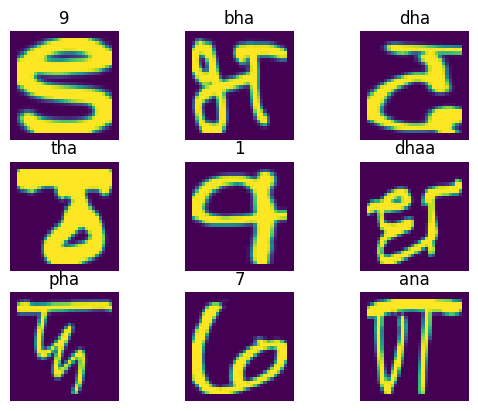

In [80]:
for images, labels in val_ds.take(1):
  for i in range(9):
    ax = plt.subplot(3, 3, i + 1)
    img = images[i].numpy().astype("uint8")
    plt.imshow(img)
#     print(images[i].numpy().astype("uint8").shape)
#     print(labels[i])    #folder ko index print garxa
#     plt.title(class_names[labels[i]]) #folder ko naam print garxa
    img_array = tf.keras.utils.img_to_array(img)
    img_array = tf.expand_dims(img_array, 0)

    class_name = int(class_names[labels[i]])
    
    predictions = new_model1.predict(img_array)
    score = tf.nn.softmax(predictions[0])
    predict = int(class_names[np.argmax(score)])
    print("Actual-" ,labels_csv.loc[class_name, 'Devanagari label']," ", "Prediction-" ,labels_csv.loc[predict, 'Devanagari label'])
    
    
    plt.title(labels_csv.loc[class_name, 'Label'])
    plt.axis("off")